# 8. Análises das Perguntas de Negócio

## 8.1 Objetivo

Este notebook utiliza o modelo dimensional construído na camada Gold para responder às perguntas de negócio definidas para o projeto.

As análises serão concentradas no período de **2005 a 2025**, abrangendo toda a série histórica consolidada no projeto e totalizando **21 anos-calendário e 252 meses de dados**.

As perguntas analisadas são:

1. Como evoluiu a produção offshore brasileira de petróleo e gás natural entre 2005 e 2025?
2. Quais estados e bacias sedimentares concentram a maior parte da produção offshore?
3. Quais campos são responsáveis pela maior parcela da produção offshore brasileira?
4. A produção offshore brasileira está se tornando mais ou menos concentrada em poucos campos ao longo do tempo?

As produções de óleo e gás natural serão analisadas separadamente, respeitando suas diferentes unidades de medida.

## 8.2 Preparação da análise

As análises deste notebook utilizam como fonte as tabelas da **camada Gold**, construídas e validadas nas etapas anteriores do projeto.

A tabela fato `workspace.gold.fato_producao` contém as medidas de produção e as chaves de relacionamento com as dimensões de tempo, campo, poço e instalação. As dimensões serão utilizadas conforme a necessidade de cada pergunta de negócio para agregar a produção sob diferentes perspectivas.

As medidas utilizadas nas análises são:

- `producao_oleo_mmbbl`: produção de óleo expressa em **milhões de barris (MMbbl)**;
- `producao_gas_bilhoes_m3`: produção total de gás natural expressa em **bilhões de metros cúbicos**.

A preparação e agregação dos dados serão realizadas utilizando **PySpark/Spark DataFrames**, enquanto as visualizações serão construídas em Python com a biblioteca **Matplotlib**.

Óleo e gás natural serão analisados separadamente nas visualizações, pois possuem unidades e escalas distintas.

## 8.3 Pergunta 1: Como evoluiu a produção offshore brasileira de petróleo e gás natural entre 2005 e 2025?

A primeira pergunta de negócio busca analisar a evolução da produção offshore brasileira de petróleo e gás natural ao longo de todo o período histórico disponível, entre 2005 e 2025.

Para isso, a produção será agregada anualmente, permitindo identificar tendências de crescimento, redução e oscilações ao longo da série histórica.

As produções de óleo e gás natural serão analisadas separadamente, respeitando suas diferentes unidades de medida: **milhões de barris (MMbbl)** para o óleo e **bilhões de metros cúbicos** para o gás natural.

### 8.3.1 Agregação anual da produção offshore

Para avaliar a evolução histórica, os volumes de óleo e gás natural disponíveis na camada Gold serão consolidados por ano.

As medidas já foram convertidas para as unidades analíticas durante a construção da camada Gold. Nesta etapa, portanto, será realizada apenas a agregação anual da produção.

In [0]:
from pyspark.sql import functions as F

# Consolida anualmente as medidas de produção disponíveis na camada Gold.
df_producao_anual = (
    spark.table("workspace.gold.fato_producao").alias("f")
    .join(
        spark.table("workspace.gold.dim_tempo").alias("t"),
        F.col("f.sk_tempo") == F.col("t.sk_tempo")
    )
    .groupBy(F.col("t.ano").alias("ano"))
    .agg(
        F.sum("f.producao_oleo_mmbbl").alias("producao_oleo_mmbbl"),
        F.sum("f.producao_gas_bilhoes_m3").alias("producao_gas_bilhoes_m3")
    )
    .orderBy("ano")
    .toPandas()
)

### 8.3.2 Visualização da evolução anual da produção

A evolução anual da produção será representada por meio de gráficos de linha, permitindo observar as tendências e oscilações ocorridas entre 2005 e 2025.

Como óleo e gás natural possuem unidades e escalas distintas, serão construídos gráficos separados para cada produto.

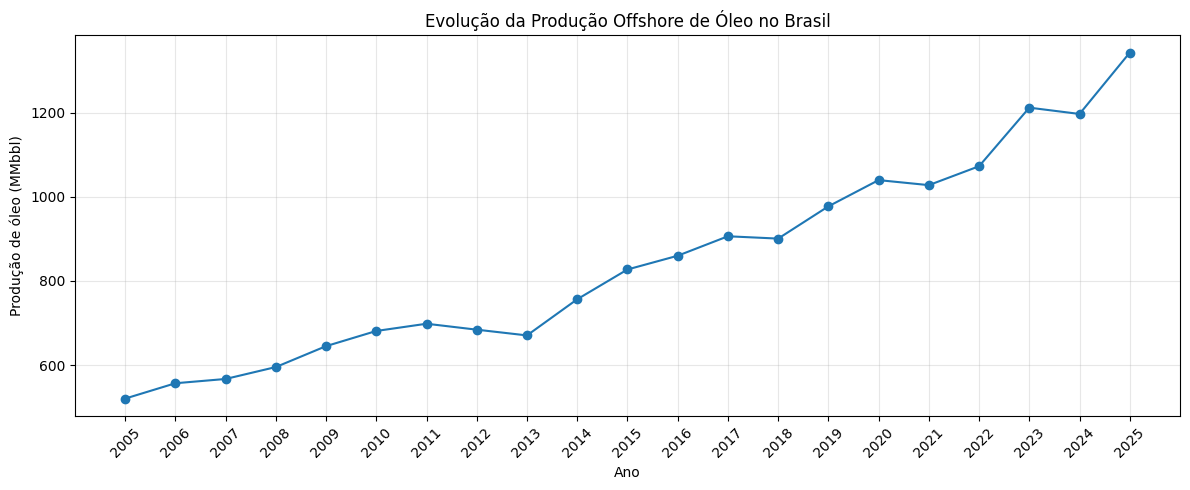

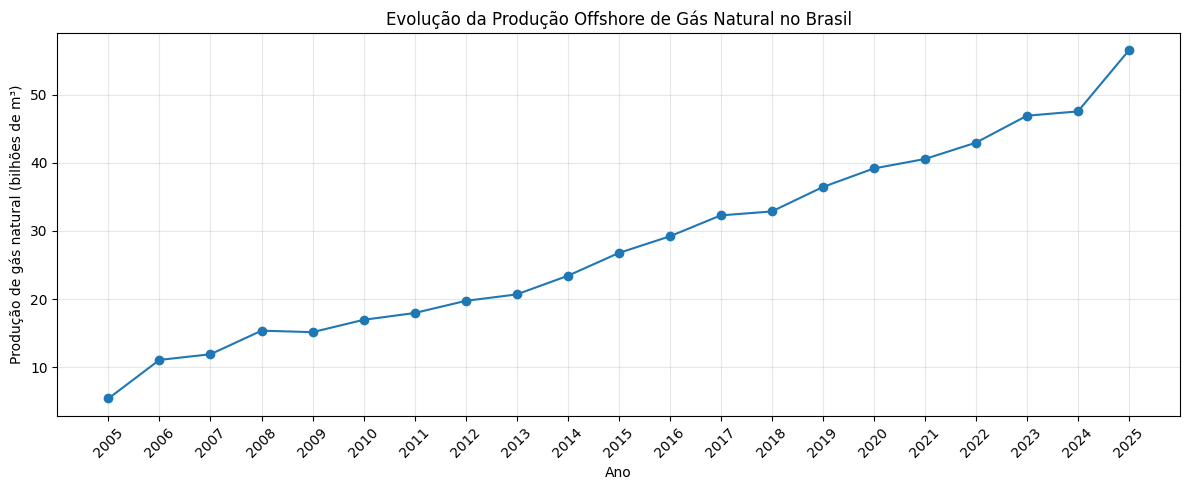

In [0]:
import matplotlib.pyplot as plt

# Representa a evolução anual da produção offshore de óleo.
plt.figure(figsize=(12, 5))

plt.plot(
    df_producao_anual["ano"],
    df_producao_anual["producao_oleo_mmbbl"],
    marker="o"
)

plt.title("Evolução da Produção Offshore de Óleo no Brasil")
plt.xlabel("Ano")
plt.ylabel("Produção de óleo (MMbbl)")
plt.xticks(df_producao_anual["ano"], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# Representa a evolução anual da produção offshore de gás natural.
plt.figure(figsize=(12, 5))

plt.plot(
    df_producao_anual["ano"],
    df_producao_anual["producao_gas_bilhoes_m3"],
    marker="o"
)

plt.title("Evolução da Produção Offshore de Gás Natural no Brasil")
plt.xlabel("Ano")
plt.ylabel("Produção de gás natural (bilhões de m³)")
plt.xticks(df_producao_anual["ano"], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### 8.3.2.1 Resultado da análise da evolução anual da produção offshore

Os gráficos evidenciam uma **expansão expressiva da produção offshore brasileira de óleo e gás natural entre 2005 e 2025**, embora as duas séries apresentem algumas diferenças em suas trajetórias.

Na produção de **óleo**, observa-se crescimento nos primeiros anos da série, seguido por um período de redução até 2013. A partir de 2014, a produção retoma uma trajetória predominantemente crescente, ainda que com algumas oscilações ao longo do período. Considerando os extremos da série, a produção passou de aproximadamente **520,20 milhões de barris em 2005 para 1.342,59 milhões de barris em 2025**.

A produção de **gás natural** apresenta crescimento mais contínuo ao longo da série. Apesar de algumas oscilações e períodos de relativa estabilidade, observa-se uma expansão acentuada principalmente na segunda metade do período analisado. A produção passou de aproximadamente **5,41 bilhões de m³ em 2005 para 56,50 bilhões de m³ em 2025**.

Dessa forma, a análise demonstra que a produção offshore brasileira **cresceu substancialmente entre 2005 e 2025 para os dois produtos**. O óleo apresentou maior presença de oscilações ao longo da série, enquanto o gás natural registrou uma trajetória de crescimento mais contínua.

## 8.4 Pergunta 2: Quais estados e bacias sedimentares concentram a maior parte da produção offshore?

A segunda pergunta de negócio busca identificar como a produção offshore brasileira está distribuída geograficamente entre os estados e as bacias sedimentares presentes na base.

Para responder à pergunta, será analisada a **evolução anual da produção entre 2005 e 2025**, permitindo identificar quais estados e bacias apresentam os maiores volumes de produção e como essa distribuição se modificou ao longo da série histórica.

A análise será realizada inicialmente por **estado** e, em seguida, por **bacia sedimentar**, possibilitando observar a concentração da produção sob duas perspectivas geográficas complementares.

A produção de óleo e a produção de gás natural serão analisadas separadamente, respeitando suas diferentes unidades de medida.

### 8.4.1 Evolução anual da produção por estado

A produção offshore de óleo e gás natural será agregada anualmente por estado, permitindo comparar a trajetória dos volumes produzidos entre 2005 e 2025.

In [0]:
# Consolida anualmente a produção offshore por estado para construção das visualizações.
df_estado_anual = spark.sql("""
    SELECT
        t.ano,
        c.estado,
        SUM(f.producao_oleo_mmbbl) AS producao_oleo_mmbbl,
        SUM(f.producao_gas_bilhoes_m3) AS producao_gas_bilhoes_m3
    FROM workspace.gold.fato_producao AS f
    INNER JOIN workspace.gold.dim_tempo AS t
        ON f.sk_tempo = t.sk_tempo
    INNER JOIN workspace.gold.dim_campo AS c
        ON f.sk_campo = c.sk_campo
    GROUP BY
        t.ano,
        c.estado
    ORDER BY
        t.ano,
        c.estado
""").toPandas()

#### 8.4.1.1 Visualização da evolução anual da produção por estado

Os gráficos a seguir apresentam a evolução anual da produção offshore de óleo e gás natural por estado entre 2005 e 2025.

As duas medidas são apresentadas em gráficos separados devido às diferentes unidades e escalas, permitindo comparar a trajetória dos estados ao longo da série histórica para cada produto.

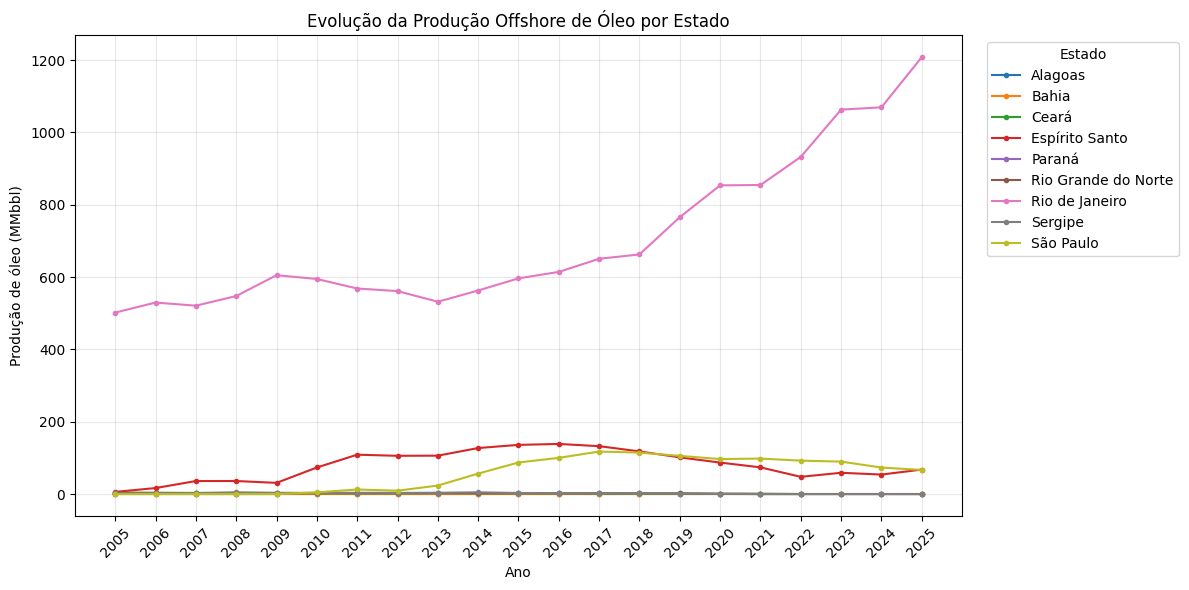

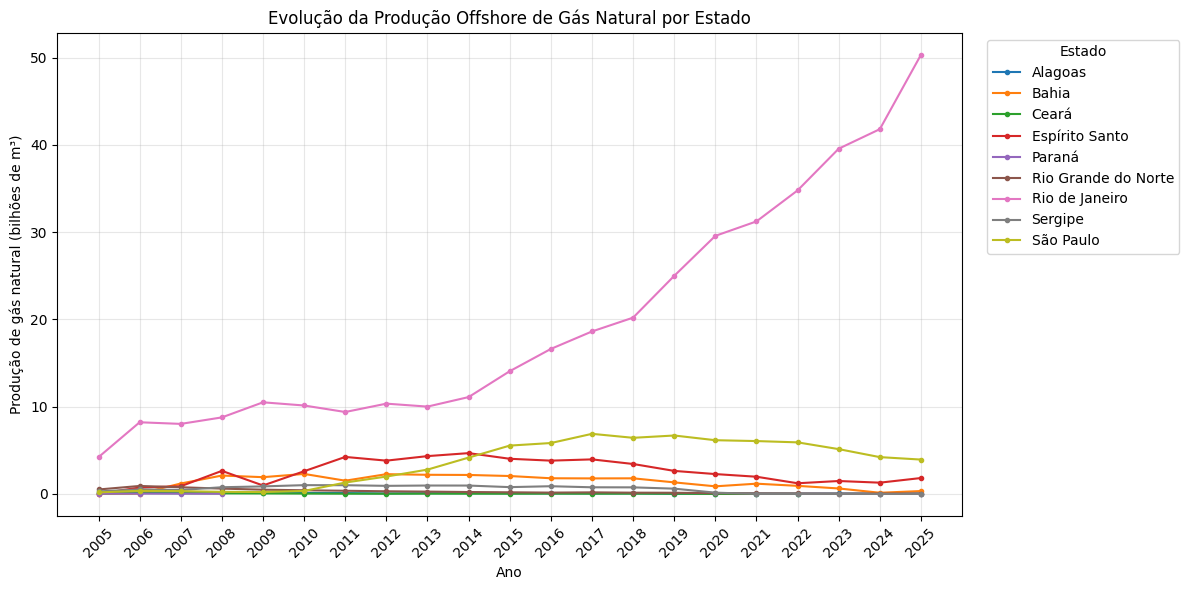

In [0]:
import matplotlib.pyplot as plt

# Organiza os dados e representa a evolução anual da produção de óleo por estado.
oleo_estado = df_estado_anual.pivot(
    index="ano",
    columns="estado",
    values="producao_oleo_mmbbl"
)

plt.figure(figsize=(12, 6))

for estado in oleo_estado.columns:
    plt.plot(
        oleo_estado.index,
        oleo_estado[estado],
        marker="o",
        markersize=3,
        label=estado
    )

plt.title("Evolução da Produção Offshore de Óleo por Estado")
plt.xlabel("Ano")
plt.ylabel("Produção de óleo (MMbbl)")
plt.xticks(oleo_estado.index, rotation=45)
plt.legend(title="Estado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Organiza os dados e representa a evolução anual da produção de gás natural por estado.
gas_estado = df_estado_anual.pivot(
    index="ano",
    columns="estado",
    values="producao_gas_bilhoes_m3"
)

plt.figure(figsize=(12, 6))

for estado in gas_estado.columns:
    plt.plot(
        gas_estado.index,
        gas_estado[estado],
        marker="o",
        markersize=3,
        label=estado
    )

plt.title("Evolução da Produção Offshore de Gás Natural por Estado")
plt.xlabel("Ano")
plt.ylabel("Produção de gás natural (bilhões de m³)")
plt.xticks(gas_estado.index, rotation=45)
plt.legend(title="Estado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

#### 8.4.1.2 Resultado da evolução anual da produção por estado

Os gráficos evidenciam uma forte concentração da produção offshore no **Rio de Janeiro**, que se mantém como o estado de maior produção ao longo da série e amplia sua distância em relação aos demais estados, especialmente na segunda metade do período analisado.

Na produção de **óleo**, o Rio de Janeiro apresenta crescimento expressivo ao longo dos anos. Após oscilações nos primeiros anos da série, observa-se uma trajetória predominantemente crescente a partir de 2013, que se intensifica nos anos seguintes. Os demais estados permanecem em patamares consideravelmente inferiores, embora Espírito Santo e São Paulo apresentem volumes relevantes em determinados períodos.

Esse comportamento coincide temporalmente com a expansão da produção do **pré-sal brasileiro**. A produção do pré-sal teve início em 2008, no campo de Jubarte, na Bacia de Campos, seguida pelo início da produção na Bacia de Santos em 2009 e pela entrada em operação do primeiro grande sistema de produção do pré-sal em 2010, no campo de Tupi. Nos anos seguintes, a produção dessa região ganhou escala de forma significativa.

Na produção de **gás natural**, observa-se comportamento semelhante. O Rio de Janeiro apresenta crescimento acentuado principalmente a partir da primeira metade da década de 2010, enquanto os demais estados permanecem em níveis substancialmente menores. Esse movimento também ocorre no período de expansão do pré-sal, cujos reservatórios produzem tanto petróleo quanto gás natural.

Informações oficiais da ANP também mostram a expansão da produção de gás natural do pré-sal ao longo desse período. Dessa forma, o aumento da produção de gás observado nos dados do projeto ocorre temporalmente em paralelo ao avanço da produção do pré-sal.

Embora os dados utilizados neste projeto não classifiquem diretamente cada registro como pré-sal ou pós-sal, a comparação com informações oficiais permite identificar uma correspondência temporal entre a expansão do pré-sal e a intensificação do crescimento observada nos gráficos, especialmente na produção associada ao Rio de Janeiro. Essa correspondência deve ser interpretada como contexto para os resultados, e não como demonstração de causalidade a partir da base analisada.

### 8.4.2 Evolução anual da produção por bacia sedimentar

A produção offshore de óleo e gás natural será agregada anualmente por bacia sedimentar, permitindo comparar a trajetória dos volumes produzidos entre 2005 e 2025.

In [0]:
# Consolida anualmente a produção offshore por bacia para construção das visualizações.
df_bacia_anual = spark.sql("""
    SELECT
        t.ano,
        c.bacia,
        SUM(f.producao_oleo_mmbbl) AS producao_oleo_mmbbl,
        SUM(f.producao_gas_bilhoes_m3) AS producao_gas_bilhoes_m3
    FROM workspace.gold.fato_producao AS f
    INNER JOIN workspace.gold.dim_tempo AS t
        ON f.sk_tempo = t.sk_tempo
    INNER JOIN workspace.gold.dim_campo AS c
        ON f.sk_campo = c.sk_campo
    GROUP BY
        t.ano,
        c.bacia
    ORDER BY
        t.ano,
        c.bacia
""").toPandas()

#### 8.4.2.1 Visualização da evolução anual da produção por bacia

Os gráficos a seguir apresentam a evolução anual da produção offshore de óleo e gás natural por bacia sedimentar entre 2005 e 2025, permitindo comparar a trajetória das diferentes bacias ao longo do período analisado.

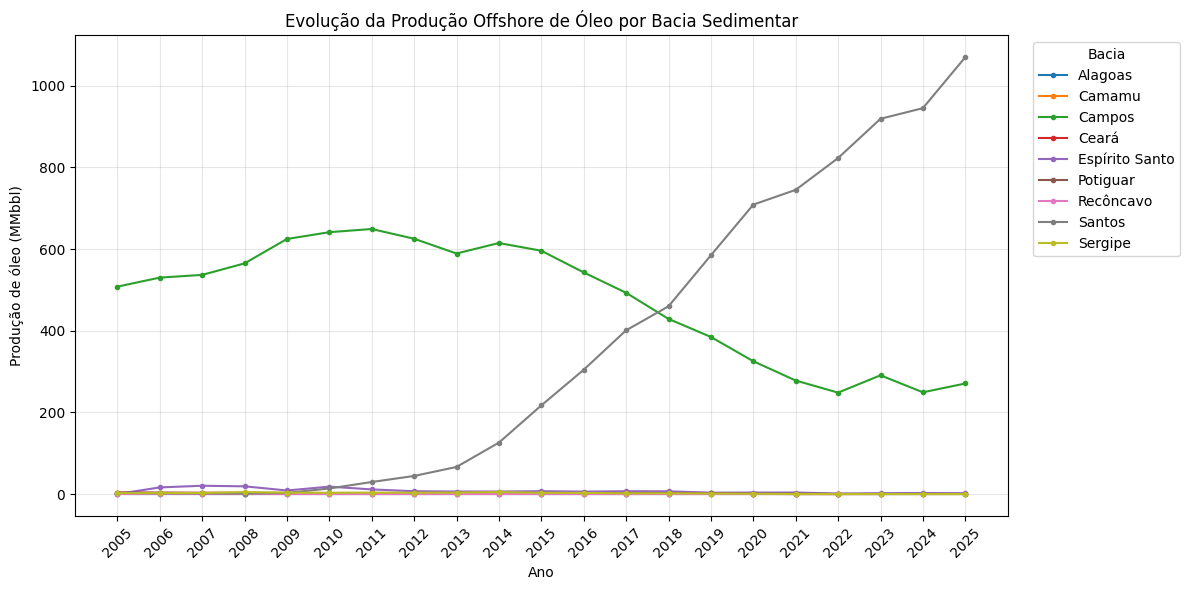

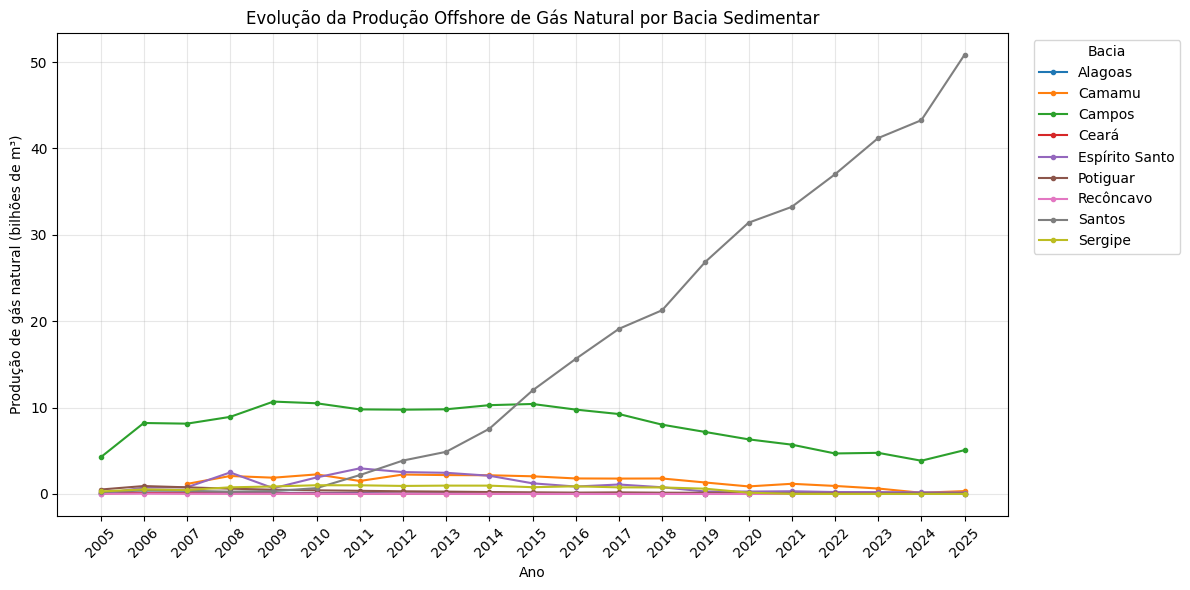

In [0]:
# Organiza os dados para representar a evolução anual da produção por bacia.
oleo_bacia = df_bacia_anual.pivot(
    index="ano",
    columns="bacia",
    values="producao_oleo_mmbbl"
)

gas_bacia = df_bacia_anual.pivot(
    index="ano",
    columns="bacia",
    values="producao_gas_bilhoes_m3"
)

# Gráfico da produção de óleo.
plt.figure(figsize=(12, 6))

for bacia in oleo_bacia.columns:
    plt.plot(
        oleo_bacia.index,
        oleo_bacia[bacia],
        marker="o",
        markersize=3,
        label=bacia
    )

plt.title("Evolução da Produção Offshore de Óleo por Bacia Sedimentar")
plt.xlabel("Ano")
plt.ylabel("Produção de óleo (MMbbl)")
plt.xticks(oleo_bacia.index, rotation=45)
plt.legend(title="Bacia", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# Gráfico da produção de gás natural.
plt.figure(figsize=(12, 6))

for bacia in gas_bacia.columns:
    plt.plot(
        gas_bacia.index,
        gas_bacia[bacia],
        marker="o",
        markersize=3,
        label=bacia
    )

plt.title("Evolução da Produção Offshore de Gás Natural por Bacia Sedimentar")
plt.xlabel("Ano")
plt.ylabel("Produção de gás natural (bilhões de m³)")
plt.xticks(gas_bacia.index, rotation=45)
plt.legend(title="Bacia", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

#### 8.4.2.2 Resultado da evolução anual da produção por bacia sedimentar

Os gráficos mostram uma mudança expressiva na distribuição da produção offshore brasileira entre as bacias sedimentares ao longo do período analisado.

No início da série, a **Bacia de Campos** concentra a maior parte da produção de óleo, mantendo volumes elevados até o início da década de 2010. A partir desse período, sua produção passa a apresentar trajetória predominantemente decrescente.

Em sentido oposto, a **Bacia de Santos** apresenta forte expansão ao longo da série. Sua produção de óleo cresce principalmente a partir da primeira metade da década de 2010, ultrapassa a Bacia de Campos e passa a apresentar, com ampla diferença, os maiores volumes ao final do período analisado.

A produção de **gás natural** apresenta comportamento semelhante. Campos predomina nos primeiros anos, enquanto Santos cresce rapidamente a partir da década de 2010, supera Campos e amplia progressivamente sua participação nos anos seguintes. Em 2025, a diferença entre Santos e as demais bacias é particularmente acentuada.

Essa transformação ocorre temporalmente em paralelo à expansão da produção do **pré-sal**, iniciada em 2008 e posteriormente ampliada, especialmente na Bacia de Santos. Como a base utilizada no projeto não identifica diretamente quais registros pertencem ao pré-sal, essa relação é utilizada como contexto externo para a interpretação dos resultados, e não como uma relação causal demonstrada pelos dados do projeto.

Assim, sob a perspectiva das bacias sedimentares, os resultados indicam uma transição da predominância histórica da **Bacia de Campos** para uma concentração crescente da produção offshore na **Bacia de Santos**, observada tanto para o óleo quanto para o gás natural.

## 8.5 Pergunta 3: Quais campos são responsáveis pela maior parcela da produção offshore brasileira?

A terceira pergunta de negócio busca identificar os campos que apresentam os maiores volumes de produção offshore brasileira.

Considerando as mudanças observadas na distribuição geográfica ao longo da série histórica, a análise utilizará o ano de **2025**, último período disponível na base, para representar a configuração mais recente da produção.

Serão identificados separadamente os **dez maiores campos produtores de óleo e de gás natural**, permitindo observar quais campos se destacam em cada produto e a quais bacias sedimentares pertencem.

### 8.5.1 Consolidação da produção por campo em 2025

Para identificar os campos responsáveis pelos maiores volumes da produção offshore mais recente, será inicialmente consolidada a produção de óleo e gás natural por campo no ano de 2025.

A consolidação mantém também as informações de estado e bacia sedimentar associadas a cada campo, permitindo posteriormente identificar a distribuição geográfica dos principais produtores.

In [0]:
# Consolida a produção offshore de óleo e gás natural por campo em 2025.
df_campo_2025 = spark.sql("""
    SELECT
        c.campo,
        c.estado,
        c.bacia,
        SUM(f.producao_oleo_mmbbl) AS producao_oleo_mmbbl,
        SUM(f.producao_gas_bilhoes_m3) AS producao_gas_bilhoes_m3
    FROM workspace.gold.fato_producao AS f
    INNER JOIN workspace.gold.dim_tempo AS t
        ON f.sk_tempo = t.sk_tempo
    INNER JOIN workspace.gold.dim_campo AS c
        ON f.sk_campo = c.sk_campo
    WHERE t.ano = 2025
    GROUP BY
        c.campo,
        c.estado,
        c.bacia
""").toPandas()

### 8.5.2 Preparação dos rankings dos campos em 2025

A partir da produção consolidada por campo em 2025, serão identificados separadamente os dez campos com maior produção de óleo e os dez campos com maior produção de gás natural.

A separação dos rankings permite preservar as diferentes unidades de medida utilizadas para cada produto e identificar a bacia sedimentar associada a cada campo.

In [0]:
# Seleciona separadamente os dez maiores campos produtores de óleo e gás natural em 2025.
top10_oleo = (
    df_campo_2025
    .nlargest(10, "producao_oleo_mmbbl")
    .sort_values("producao_oleo_mmbbl", ascending=True)
)

top10_gas = (
    df_campo_2025
    .nlargest(10, "producao_gas_bilhoes_m3")
    .sort_values("producao_gas_bilhoes_m3", ascending=True)
)

#### 8.5.3 Visualização dos principais campos produtores em 2025

Os gráficos a seguir apresentam os dez campos com os maiores volumes de produção offshore de óleo e gás natural em 2025.

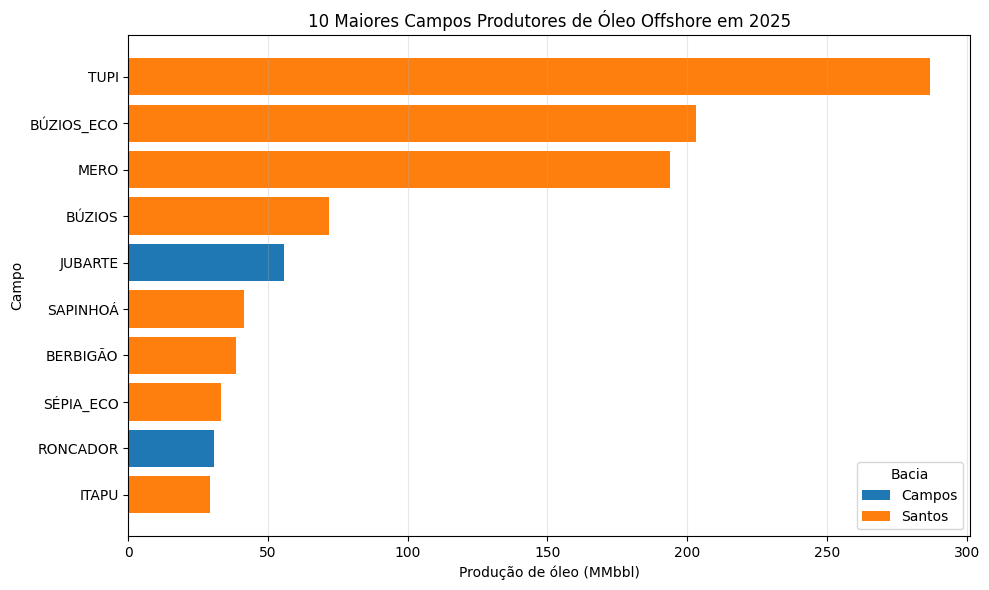

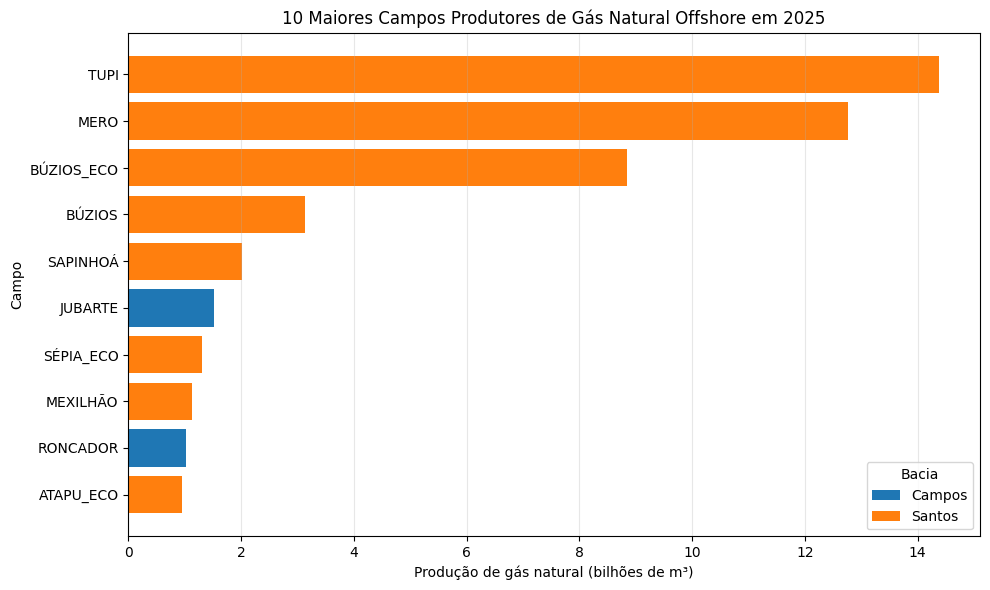

In [0]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Cria uma identificação visual consistente para cada bacia presente nos rankings.
bacias = sorted(
    set(top10_oleo["bacia"]).union(set(top10_gas["bacia"]))
)

cores = plt.cm.tab10(range(len(bacias)))
cor_bacia = dict(zip(bacias, cores))

legenda = [
    Patch(facecolor=cor_bacia[bacia], label=bacia)
    for bacia in bacias
]


# Gráfico dos maiores produtores de óleo.
plt.figure(figsize=(10, 6))

plt.barh(
    top10_oleo["campo"],
    top10_oleo["producao_oleo_mmbbl"],
    color=[cor_bacia[bacia] for bacia in top10_oleo["bacia"]]
)

plt.title("10 Maiores Campos Produtores de Óleo Offshore em 2025")
plt.xlabel("Produção de óleo (MMbbl)")
plt.ylabel("Campo")
plt.legend(handles=legenda, title="Bacia")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()


# Gráfico dos maiores produtores de gás natural.
plt.figure(figsize=(10, 6))

plt.barh(
    top10_gas["campo"],
    top10_gas["producao_gas_bilhoes_m3"],
    color=[cor_bacia[bacia] for bacia in top10_gas["bacia"]]
)

plt.title("10 Maiores Campos Produtores de Gás Natural Offshore em 2025")
plt.xlabel("Produção de gás natural (bilhões de m³)")
plt.ylabel("Campo")
plt.legend(handles=legenda, title="Bacia")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### 8.5.4 Resultado dos principais campos produtores em 2025

Os rankings mostram uma forte presença da **Bacia de Santos** entre os principais campos produtores offshore em 2025. Dos dez maiores campos produtores de óleo, oito pertencem à Bacia de Santos, enquanto Jubarte e Roncador pertencem à Bacia de Campos. A mesma distribuição é observada entre os dez maiores produtores de gás natural.

O campo de **Tupi** ocupa a primeira posição nos dois rankings, apresentando o maior volume de produção tanto de óleo quanto de gás natural. Mero e Búzios_ECO também se destacam entre os maiores produtores dos dois produtos.

O resultado complementa a análise geográfica anterior. A predominância da Bacia de Santos observada ao final da série histórica não está distribuída uniformemente entre todos os seus campos, mas é sustentada por um conjunto de campos com volumes de produção particularmente elevados.

A presença recorrente dos mesmos campos entre os maiores produtores de óleo e gás também evidencia que parte importante da produção offshore atual dos dois produtos está associada aos mesmos campos.

Dessa forma, em 2025, os maiores volumes da produção offshore brasileira estão fortemente associados a campos da **Bacia de Santos**, com destaque para Tupi, Mero e Búzios_ECO.

## 8.6 Pergunta 4: A produção offshore brasileira está se tornando mais ou menos concentrada em poucos campos ao longo do tempo?

A quarta pergunta de negócio busca avaliar como a concentração da produção offshore entre os campos se modificou ao longo do período de 2005 a 2025.

Para isso, será calculada anualmente a participação dos **cinco maiores campos (Top 5)** e dos **dez maiores campos (Top 10)** na produção total de óleo e gás natural.

O uso dos dois grupos permite observar diferentes níveis de concentração. O **Top 5** representa um conjunto mais restrito de grandes produtores e permite avaliar quanto da produção está concentrada em poucos campos. O **Top 10** amplia esse grupo e permite verificar quanto os cinco campos seguintes acrescentam à participação dos principais produtores.

Dessa forma, a comparação entre Top 5 e Top 10 ajuda a identificar se a produção está fortemente concentrada nos primeiros colocados ou distribuída entre um conjunto um pouco maior de campos.

Quanto maior a participação desses grupos na produção total, maior é a concentração observada. A evolução anual desses percentuais permitirá avaliar como essa concentração se modificou ao longo da série histórica.

Os percentuais de Top 5 e Top 10 serão utilizados como **medidas de participação dos maiores produtores**, e não como um índice estatístico formal de concentração.

### 8.6.1 Cálculo da concentração anual da produção por campo

A produção será inicialmente consolidada por ano e campo. Em seguida, os campos serão ordenados de acordo com o volume produzido em cada ano para calcular a participação dos cinco e dos dez maiores produtores na produção total anual.

O cálculo será realizado separadamente para óleo e gás natural, permitindo avaliar a evolução da concentração de cada produto.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Consolida a produção anual de cada campo.
df_campo_anual = (
    spark.table("workspace.gold.fato_producao").alias("f")
    .join(
        spark.table("workspace.gold.dim_tempo").alias("t"),
        F.col("f.sk_tempo") == F.col("t.sk_tempo")
    )
    .join(
        spark.table("workspace.gold.dim_campo").alias("c"),
        F.col("f.sk_campo") == F.col("c.sk_campo")
    )
    .groupBy(
        F.col("t.ano").alias("ano"),
        F.col("c.campo").alias("campo")
    )
    .agg(
        F.sum("f.producao_oleo_mmbbl").alias("producao_oleo_mmbbl"),
        F.sum("f.producao_gas_bilhoes_m3").alias("producao_gas_bilhoes_m3")
    )
)

# Define rankings anuais independentes para óleo e gás natural.
janela_oleo = Window.partitionBy("ano").orderBy(
    F.col("producao_oleo_mmbbl").desc()
)

janela_gas = Window.partitionBy("ano").orderBy(
    F.col("producao_gas_bilhoes_m3").desc()
)

df_ranking = (
    df_campo_anual
    .withColumn("rank_oleo", F.row_number().over(janela_oleo))
    .withColumn("rank_gas", F.row_number().over(janela_gas))
)

# Calcula a participação anual dos Top 5 e Top 10 campos.
df_concentracao = (
    df_ranking
    .groupBy("ano")
    .agg(
        F.sum("producao_oleo_mmbbl").alias("oleo_total"),
        F.sum(
            F.when(F.col("rank_oleo") <= 5, F.col("producao_oleo_mmbbl")).otherwise(0)
        ).alias("oleo_top5"),
        F.sum(
            F.when(F.col("rank_oleo") <= 10, F.col("producao_oleo_mmbbl")).otherwise(0)
        ).alias("oleo_top10"),

        F.sum("producao_gas_bilhoes_m3").alias("gas_total"),
        F.sum(
            F.when(F.col("rank_gas") <= 5, F.col("producao_gas_bilhoes_m3")).otherwise(0)
        ).alias("gas_top5"),
        F.sum(
            F.when(F.col("rank_gas") <= 10, F.col("producao_gas_bilhoes_m3")).otherwise(0)
        ).alias("gas_top10")
    )
    .withColumn(
        "oleo_top5_pct",
        F.col("oleo_top5") / F.col("oleo_total") * 100
    )
    .withColumn(
        "oleo_top10_pct",
        F.col("oleo_top10") / F.col("oleo_total") * 100
    )
    .withColumn(
        "gas_top5_pct",
        F.col("gas_top5") / F.col("gas_total") * 100
    )
    .withColumn(
        "gas_top10_pct",
        F.col("gas_top10") / F.col("gas_total") * 100
    )
    .orderBy("ano")
    .toPandas()
)

### 8.6.2 Visualização da evolução da concentração da produção

Os gráficos a seguir apresentam a participação anual dos **cinco** e dos **dez maiores campos produtores** na produção offshore total de óleo e gás natural.

A evolução desses percentuais permite observar se a produção passou a se concentrar em um grupo menor de campos ou se se tornou mais distribuída ao longo do período analisado.

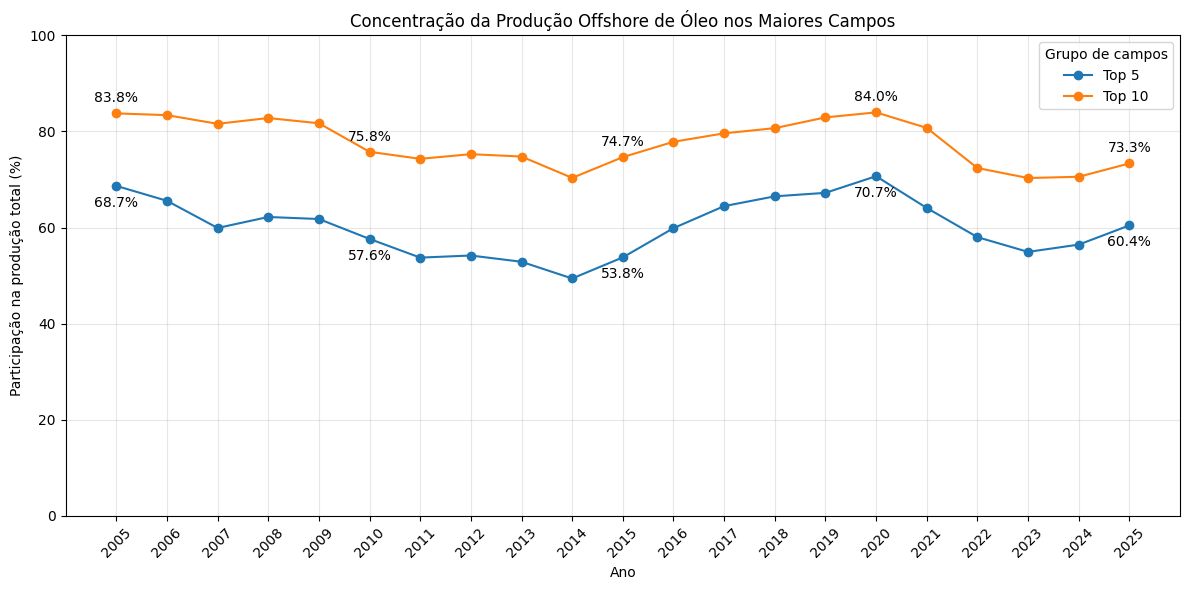

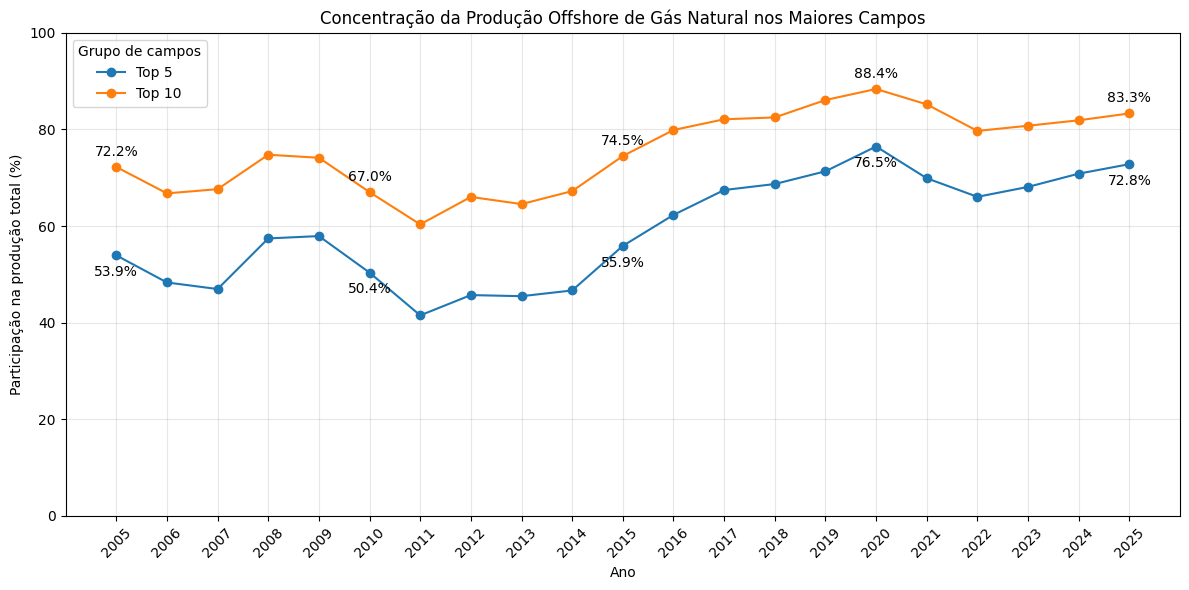

In [0]:
import matplotlib.pyplot as plt

# Anos selecionados para destacar os percentuais sem sobrecarregar os gráficos.
anos_rotulo = [2005, 2010, 2015, 2020, 2025]


# Gráfico da concentração da produção de óleo.
plt.figure(figsize=(12, 6))

plt.plot(
    df_concentracao["ano"],
    df_concentracao["oleo_top5_pct"],
    marker="o",
    label="Top 5"
)

plt.plot(
    df_concentracao["ano"],
    df_concentracao["oleo_top10_pct"],
    marker="o",
    label="Top 10"
)

# Adiciona rótulos nos anos selecionados.
for _, linha in df_concentracao[
    df_concentracao["ano"].isin(anos_rotulo)
].iterrows():

    plt.annotate(
        f'{linha["oleo_top5_pct"]:.1f}%',
        (linha["ano"], linha["oleo_top5_pct"]),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center"
    )

    plt.annotate(
        f'{linha["oleo_top10_pct"]:.1f}%',
        (linha["ano"], linha["oleo_top10_pct"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title("Concentração da Produção Offshore de Óleo nos Maiores Campos")
plt.xlabel("Ano")
plt.ylabel("Participação na produção total (%)")
plt.xticks(df_concentracao["ano"], rotation=45)
plt.ylim(0, 100)
plt.legend(title="Grupo de campos")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


# Gráfico da concentração da produção de gás natural.
plt.figure(figsize=(12, 6))

plt.plot(
    df_concentracao["ano"],
    df_concentracao["gas_top5_pct"],
    marker="o",
    label="Top 5"
)

plt.plot(
    df_concentracao["ano"],
    df_concentracao["gas_top10_pct"],
    marker="o",
    label="Top 10"
)

# Adiciona rótulos nos anos selecionados.
for _, linha in df_concentracao[
    df_concentracao["ano"].isin(anos_rotulo)
].iterrows():

    plt.annotate(
        f'{linha["gas_top5_pct"]:.1f}%',
        (linha["ano"], linha["gas_top5_pct"]),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center"
    )

    plt.annotate(
        f'{linha["gas_top10_pct"]:.1f}%',
        (linha["ano"], linha["gas_top10_pct"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.title("Concentração da Produção Offshore de Gás Natural nos Maiores Campos")
plt.xlabel("Ano")
plt.ylabel("Participação na produção total (%)")
plt.xticks(df_concentracao["ano"], rotation=45)
plt.ylim(0, 100)
plt.legend(title="Grupo de campos")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### 8.6.3 Resultado da evolução da concentração da produção

Os resultados mostram que a produção offshore brasileira é **fortemente concentrada em um número reduzido de campos**, tanto para o óleo quanto para o gás natural. Ao longo de toda a série, os cinco e os dez maiores campos respondem por parcelas expressivas da produção total.

Essa concentração, entretanto, **não apresenta uma trajetória contínua de aumento ou redução entre 2005 e 2025**. Os dois produtos apresentam comportamento semelhante, com períodos de diminuição da participação dos maiores campos, seguidos por novos períodos de crescimento da concentração.

A comparação entre Top 5 e Top 10 reforça esse resultado, pois uma parcela significativa da produção já está concentrada apenas nos cinco maiores produtores. Em 2025, por exemplo, os cinco maiores campos respondem por **60,4% da produção de óleo e 72,8% da produção de gás natural**, evidenciando uma concentração ainda maior para o gás ao final da série.

Portanto, a produção offshore brasileira **permanece concentrada em poucos campos ao longo de todo o período analisado**, embora o grau dessa concentração varie ao longo dos anos. Os dados não indicam uma tendência única de aumento ou redução da concentração entre 2005 e 2025.

## 8.7 Síntese dos resultados

As análises realizadas permitem construir uma visão integrada da evolução e da distribuição da produção offshore brasileira de petróleo e gás natural entre 2005 e 2025.

A primeira análise mostrou uma **expansão expressiva da produção offshore ao longo do período**, tanto para óleo quanto para gás natural. Embora existam oscilações ao longo da série, os volumes produzidos em 2025 são substancialmente superiores aos observados no início do período.

Sob a perspectiva geográfica, os resultados evidenciam uma **forte concentração da produção no Rio de Janeiro** e uma transformação relevante entre as principais bacias produtoras. A Bacia de Campos, predominante nos primeiros anos da série, perde participação ao longo do período, enquanto a **Bacia de Santos apresenta forte crescimento e passa a concentrar os maiores volumes de produção ao final da série**.

A análise dos campos produtores reforça esse resultado. Em 2025, a maior parte dos dez principais campos produtores de óleo e gás natural pertence à **Bacia de Santos**, com destaque para campos como Tupi, Mero e Búzios_ECO.

Por fim, a análise da participação dos maiores campos demonstra que a produção offshore brasileira **permanece fortemente concentrada em um número reduzido de campos**, embora o grau dessa concentração apresente oscilações ao longo do tempo. Não foi identificada uma tendência contínua de aumento ou redução da concentração durante todo o período analisado.

Em conjunto, os resultados mostram que o crescimento da produção offshore brasileira entre 2005 e 2025 ocorreu acompanhado por uma **mudança na distribuição geográfica da produção, com aumento da relevância da Bacia de Santos, e pela manutenção de uma estrutura produtiva concentrada em poucos campos de grande produção**.

## 8.8 Fontes complementares utilizadas na interpretação

Além dos dados da ANP utilizados na construção do Lakehouse, foram consultadas fontes oficiais complementares para contextualizar os resultados relacionados à expansão da produção offshore brasileira e ao desenvolvimento do pré-sal.

Essas informações foram utilizadas exclusivamente como **contexto externo para interpretação dos resultados**. A base utilizada no projeto não possui uma classificação direta dos registros entre pré-sal e pós-sal e, portanto, não permite atribuir causalidade entre a expansão do pré-sal e os comportamentos observados nas análises.

### Fontes consultadas

**Petrobras — Pré-sal**  
https://petrobras.com.br/pre-sal

Apresenta informações sobre o pré-sal brasileiro e sua evolução histórica, incluindo o início da produção em 2008 no campo de Jubarte, na Bacia de Campos, e em 2009 na Bacia de Santos.

**Petrobras — 15 anos de produção do pré-sal**  
https://agencia.petrobras.com.br/pt/w/institucional/petrobras-comemora-15-anos-de-producao-do-pre-sal

Apresenta o histórico da produção do pré-sal desde o primeiro óleo produzido em setembro de 2008 no campo de Jubarte e sua posterior expansão.

**ANP — Produção de Petróleo e Gás Natural por Poço**  
https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/producao-de-petroleo-e-gas-natural-por-poco

Disponibiliza dados oficiais de produção de petróleo e gás natural por poço e informa a existência de dados específicos de produção no pré-sal como subconjunto da produção marítima.